In [ ]:
import cv2
import numpy as np
def ImageHist(image,type):
    color = (255,255,255)
    windowName = 'Gray'
    if type == 31:
        color = (255,0,0)
        windowName = 'B Hist'
    elif type == 32:
        color = (0,255,0)
        windowName = 'G Hist'
    elif type == 33:
        color = (0,0,255)
        windowName = 'R Hist'
    # 1 image 2 [0] 3 mask None 4 256 5 0-255
    hist = cv2.calcHist([image],[0],None,[256],[0.0,255.0])
    minV,maxV,minL,maxL = cv2.minMaxLoc(hist)
    histImg = np.zeros([256,256,3],np.uint8)
    for h in range(256):
        # 归一化到0-255
        intenNormal = int(hist[h]*256/maxV)
        cv2.line(histImg,(h,256),(h,256-intenNormal),color)
    cv2.imshow(windowName,histImg)
    return histImg
img = cv2.imread('/Users/xh/workspaces/jupyter/opencv-example/2入门/opencv入门/image0.JPG', 1)
channels = cv2.split(img)# RGB - R G B
for i in range(0,3):
    ImageHist(channels[i],31+i)
cv2.waitKey(0)

In [1]:
import cv2
import numpy as np

def draw_histogram(image, color, title):
    """绘制单个通道的直方图"""
    hist = cv2.calcHist([image], [0], None, [256], [0.0, 255.0])
    maxV = np.max(hist)

    histImg = np.zeros([256, 256, 3], np.uint8)

    if maxV > 0:
        for h in range(256):
            intenNormal = int(hist[h] * 255 / maxV)
            cv2.line(histImg, (h, 255), (h, 255 - intenNormal), color, 1)

    # 添加标题（在图像上写文字）
    cv2.putText(histImg, title, (10, 20),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1)

    return histImg

img = cv2.imread('/Users/xh/workspaces/jupyter/opencv-example/2入门/opencv入门/image0.JPG', 1)
b, g, r = cv2.split(img)

# 分别绘制三个直方图
b_hist = draw_histogram(b, (255, 0, 0), 'Blue')
g_hist = draw_histogram(g, (0, 255, 0), 'Green')
r_hist = draw_histogram(r, (0, 0, 255), 'Red')

# 水平拼接
top_row = np.hstack([b_hist, g_hist])
bottom_row = np.hstack([r_hist, np.zeros((256, 256, 3), np.uint8)])
combined = np.vstack([top_row, bottom_row])

cv2.imshow('RGB Histograms', combined)
cv2.waitKey(0)
cv2.destroyAllWindows()

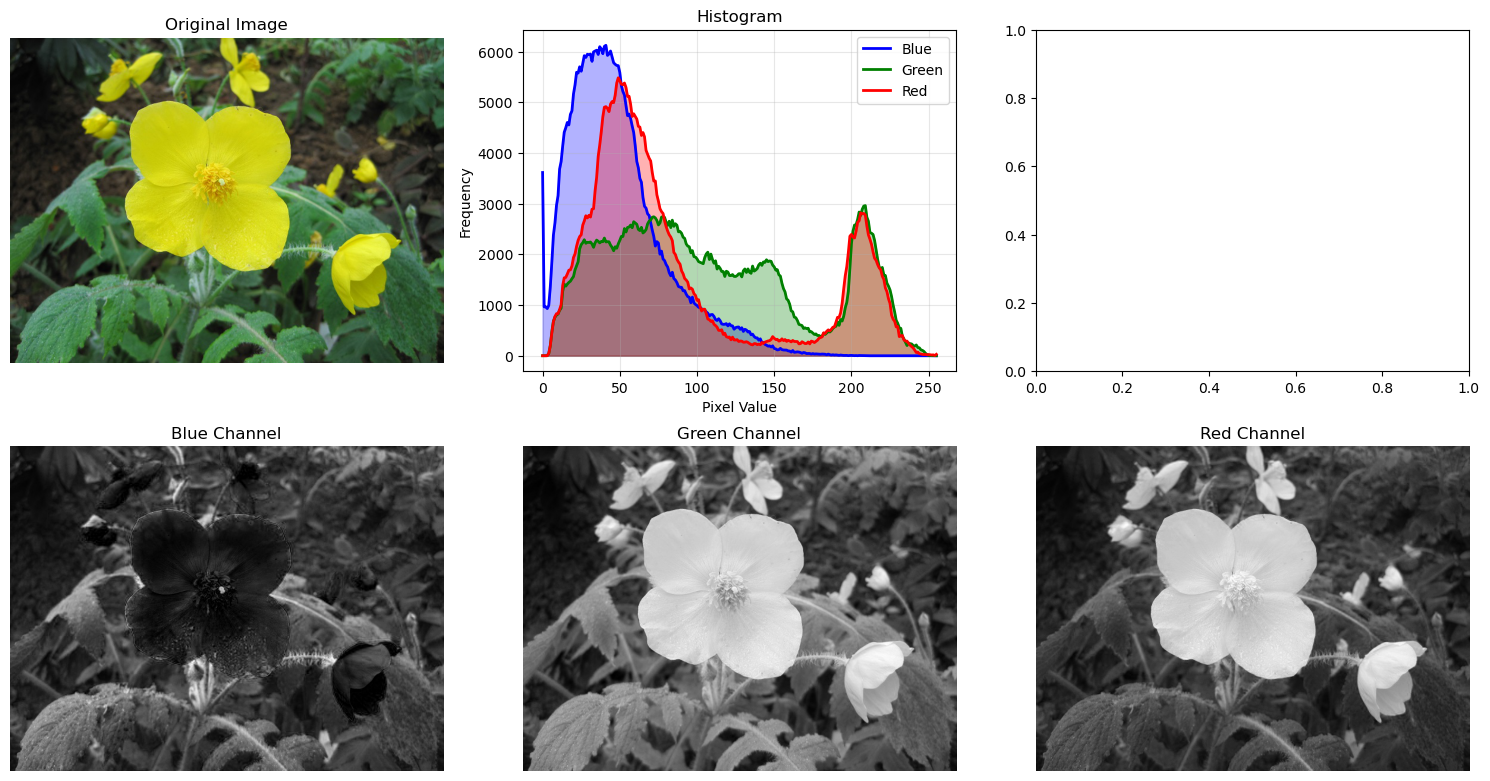

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def plot_histogram_with_matplotlib(img):
    """
    使用matplotlib绘制直方图
    """
    # 分离通道
    b, g, r = cv2.split(img)

    # ✅ 改为 2行3列
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))

    # 1. 原图
    axes[0, 0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[0, 0].set_title('Original Image')
    axes[0, 0].axis('off')

    # 2. 直方图
    colors = ('blue', 'green', 'red')
    channels = (b, g, r)
    titles = ('Blue', 'Green', 'Red')

    for channel, color, title in zip(channels, colors, titles):
        hist = cv2.calcHist([channel], [0], None, [256], [0, 256])
        axes[0, 1].plot(hist, color=color, label=title, linewidth=2)
        axes[0, 1].fill_between(range(256), hist.flatten(), alpha=0.3, color=color)

    axes[0, 1].set_title('Histogram')
    axes[0, 1].set_xlabel('Pixel Value')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # 3-5. 各通道单独显示（3列：0,1,2）
    for i, (channel, title) in enumerate(zip(channels, titles)):
        axes[1, i].imshow(channel, cmap='gray')
        axes[1, i].set_title(f'{title} Channel')
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()

# 使用
img = cv2.imread('/Users/xh/workspaces/jupyter/opencv-example/2入门/opencv入门/image0.JPG', 1)
plot_histogram_with_matplotlib(img)